# 01 — Corpus Exploration

Understand the raw material before building anything on top of it.

**What this notebook covers:**
- Document inventory and word counts
- Chunk distribution analysis
- Risk tier and deadline coverage
- Cross-reference network
- Sample inspection of key articles (Art. 5, 6, 50, Annex III)

In [2]:
import json
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

with open('../data/processed/chunks_dump.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)

df = pd.DataFrame(chunks)
print(f'Loaded {len(df)} chunks')
df.dtypes

Loaded 814 chunks


id                   str
level              int64
doc_id               str
article_num          str
paragraph_num        str
word_count         int64
context_header       str
text                 str
text_to_embed        str
risk_tiers        object
deadline             str
cross_refs        object
title             object
chapter              str
section              str
article_name         str
doc_type             str
is_normative        bool
dtype: object

## 1. Document inventory

In [3]:
doc_stats = df.groupby('doc_id').agg(
    chunks=('id', 'count'),
    total_words=('word_count', 'sum'),
    avg_words=('word_count', 'mean'),
    max_words=('word_count', 'max'),
).round(1)

print('Corpus document breakdown:')
print(doc_stats.to_string())
print(f'\nTotal: {len(df)} chunks | {df["word_count"].sum():,} words')

Corpus document breakdown:
                       chunks  total_words  avg_words  max_words
doc_id                                                          
ai_act                    727       108841      149.7       4969
gpai_cop_copyright          5         2082      416.4        511
gpai_cop_safety            42        15403      366.7        541
gpai_cop_transparency       5         1689      337.8        510
gpai_guidelines            35        15483      442.4        549

Total: 814 chunks | 143,498 words


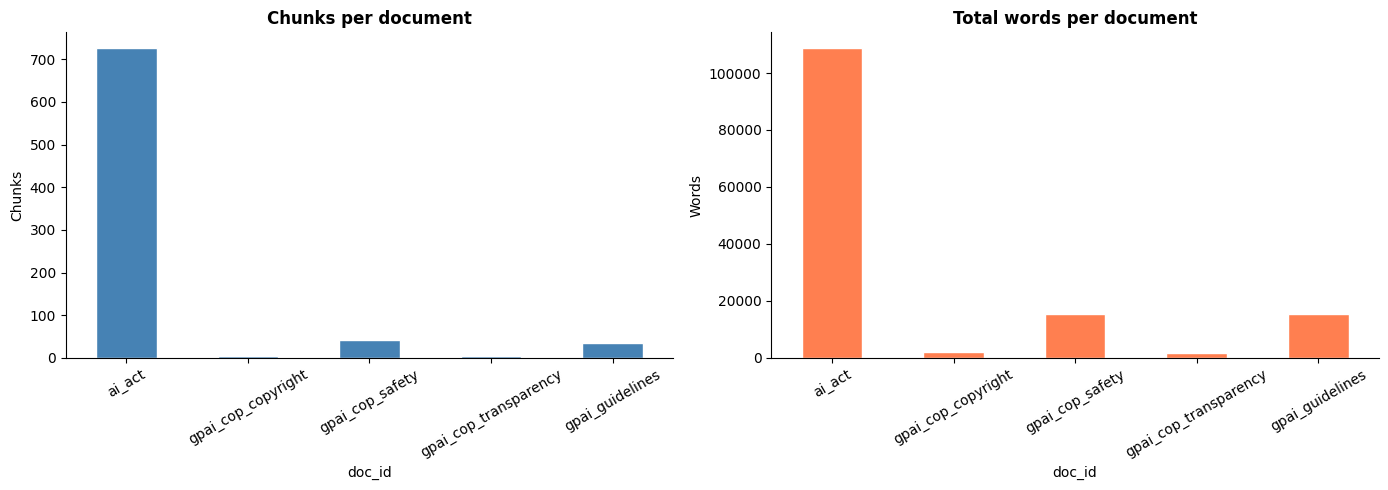

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

doc_stats['chunks'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Chunks per document', fontweight='bold')
axes[0].set_ylabel('Chunks')
axes[0].tick_params(axis='x', rotation=30)

doc_stats['total_words'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total words per document', fontweight='bold')
axes[1].set_ylabel('Words')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/fig_01_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Chunk level and word count distribution

  Level 1 (Article / Annex): 127 chunks (15.6%)
  Level 2 (Paragraph): 687 chunks (84.4%)


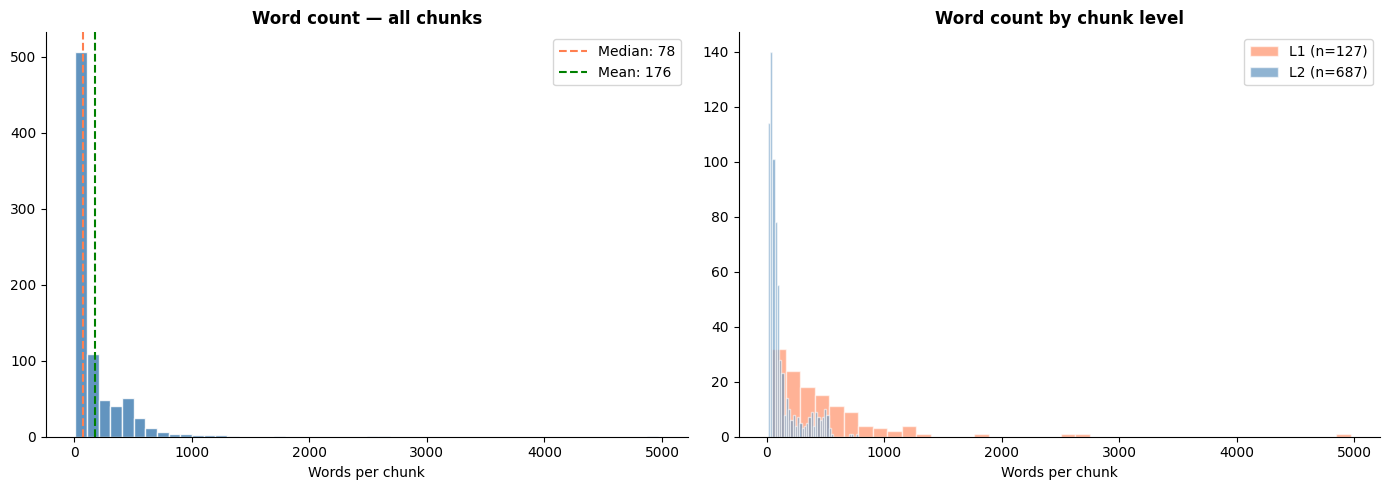

count     814.0
mean      176.3
std       292.4
min        10.0
25%        42.0
50%        78.5
75%       201.0
max      4969.0


In [5]:
level_counts = df['level'].value_counts().sort_index()
for lvl, count in level_counts.items():
    label = 'Article / Annex' if lvl == 1 else 'Paragraph'
    print(f'  Level {lvl} ({label}): {count} chunks ({count/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='coral', linestyle='--',
                linewidth=1.5, label=f"Median: {df['word_count'].median():.0f}")
axes[0].axvline(df['word_count'].mean(), color='green', linestyle='--',
                linewidth=1.5, label=f"Mean: {df['word_count'].mean():.0f}")
axes[0].set_title('Word count — all chunks', fontweight='bold')
axes[0].set_xlabel('Words per chunk')
axes[0].legend()

for lvl, color in [(1, 'coral'), (2, 'steelblue')]:
    subset = df[df['level'] == lvl]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color,
                 label=f'L{lvl} (n={len(subset)})', edgecolor='white')
axes[1].set_title('Word count by chunk level', fontweight='bold')
axes[1].set_xlabel('Words per chunk')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_01_word_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['word_count'].describe().round(1).to_string())

## 3. Risk tier and deadline coverage

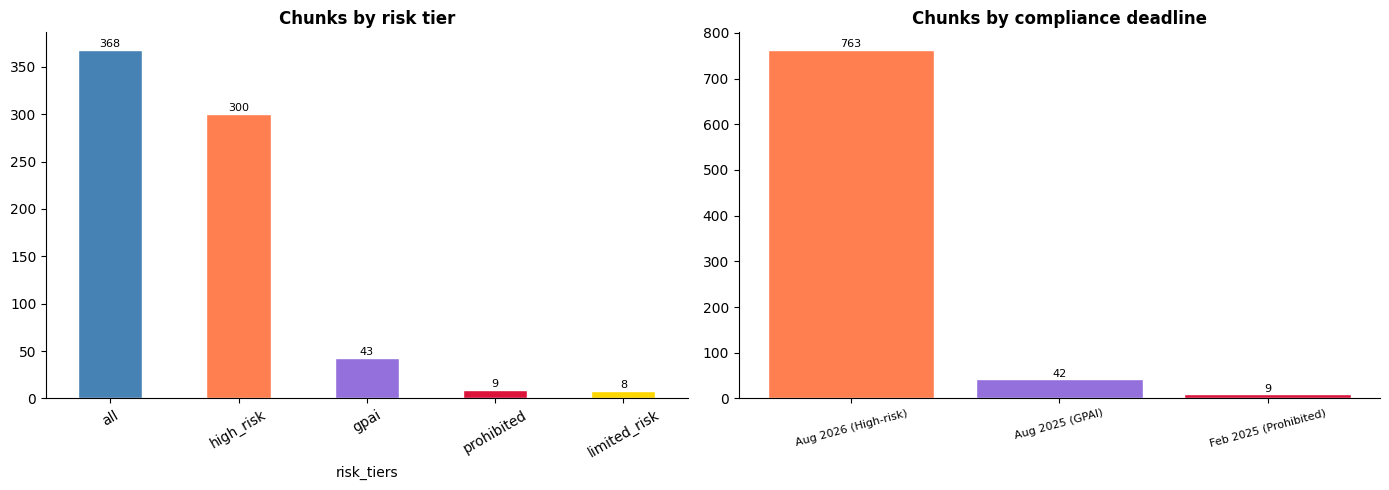

In [6]:
risk_counts = df['risk_tiers'].explode().value_counts()
colors = {'high_risk': 'coral', 'all': 'steelblue', 'limited_risk': 'gold',
          'prohibited': 'crimson', 'gpai': 'mediumpurple', 'minimal_risk': 'lightgreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = [colors.get(t, 'gray') for t in risk_counts.index]
risk_counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_title('Chunks by risk tier', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(axes[0].patches, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=8)

deadline_labels = {
    '2025-02-02': 'Feb 2025 (Prohibited)',
    '2025-08-02': 'Aug 2025 (GPAI)',
    '2026-08-02': 'Aug 2026 (High-risk)',
    '2027-08-02': 'Aug 2027 (Products)',
}
deadline_colors = {'2025-02-02': 'crimson', '2025-08-02': 'mediumpurple',
                   '2026-08-02': 'coral', '2027-08-02': 'steelblue'}
dl_counts = df['deadline'].value_counts()
dl_labels = [deadline_labels.get(d, d) for d in dl_counts.index]
dl_colors = [deadline_colors.get(d, 'gray') for d in dl_counts.index]
bars = axes[1].bar(range(len(dl_counts)), dl_counts.values, color=dl_colors, edgecolor='white')
axes[1].set_xticks(range(len(dl_counts)))
axes[1].set_xticklabels(dl_labels, fontsize=8, rotation=15)
axes[1].set_title('Chunks by compliance deadline', fontweight='bold')
for bar, v in zip(bars, dl_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_01_risk_deadlines.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-reference network (top 20)

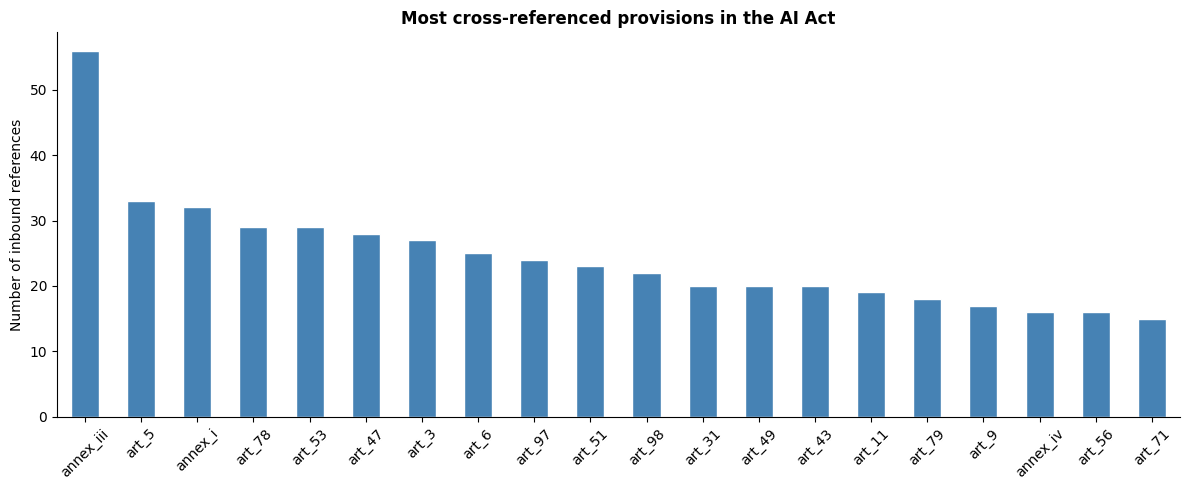

Top 10 most referenced provisions:
  annex_iii                 — referenced 56 times
  art_5                     — referenced 33 times
  annex_i                   — referenced 32 times
  art_78                    — referenced 29 times
  art_53                    — referenced 29 times
  art_47                    — referenced 28 times
  art_3                     — referenced 27 times
  art_6                     — referenced 25 times
  art_97                    — referenced 24 times
  art_51                    — referenced 23 times


In [7]:
all_refs = [ref for refs in df['cross_refs'] if isinstance(refs, list) for ref in refs]
top_refs = pd.Series(Counter(all_refs)).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_refs.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Most cross-referenced provisions in the AI Act', fontweight='bold')
ax.set_ylabel('Number of inbound references')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/fig_01_cross_refs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most referenced provisions:')
for ref, count in top_refs.head(10).items():
    print(f'  {ref:25s} — referenced {count} times')

## 5. Key article inspection

In [8]:
def show_chunk(chunk_id):
    row = df[df['id'] == chunk_id]
    if row.empty:
        print(f'Not found: {chunk_id}')
        candidates = df[df['id'].str.startswith(chunk_id[:15])]['id'].tolist()
        if candidates: print(f'Similar IDs: {candidates[:5]}')
        return
    r = row.iloc[0]
    print(f'{'='*65}')
    print(f'ID: {r["id"]}  |  Level: {r["level"]}  |  Words: {r["word_count"]}')
    print(f'Risk tiers:  {r["risk_tiers"]}')
    print(f'Deadline:    {r["deadline"]}')
    print(f'Cross-refs:  {r["cross_refs"]}')
    print(f'{'='*65}')
    print('Context header:')
    print(r['context_header'])
    print('\nText (first 500 chars):')
    print(r['text'][:500])

show_chunk('ai_act_art5')

ID: ai_act_art5  |  Level: 1  |  Words: 1781
Risk tiers:  ['prohibited']
Deadline:    2025-02-02
Cross-refs:  ['annex_ii', 'art_27', 'art_49', 'art_5', 'art_9']
Context header:
[Chapter II — PROHIBITED AI PRACTICES]
[Article 5 — Prohibited AI practices]

Text (first 500 chars):
Article 5
Prohibited AI practices
1.
The following AI practices shall be prohibited:
(a) the placing on the market, the putting into service or the use of an AI system that deploys subliminal techniques beyond 
a person’s consciousness or purposefully manipulative or deceptive techniques, with the objective, or the effect of 
materially distorting the behaviour of a person or a group of persons by appreciably impairing their ability to make an 
informed decision, thereby causing them to take a d


In [9]:
show_chunk('ai_act_art6')

ID: ai_act_art6  |  Level: 1  |  Words: 674
Risk tiers:  ['high_risk']
Deadline:    2026-08-02
Cross-refs:  ['annex_i', 'annex_iii', 'art_49', 'art_6', 'art_7', 'art_96', 'art_97']
Context header:
[Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems as high-risk]
[Article 6 — Classification rules for high-risk AI systems]

Text (first 500 chars):
Article 6
Classification rules for high-risk AI systems
1.
Irrespective of whether an AI system is placed on the market or put into service independently of the products 
referred to in points (a) and (b), that AI system shall be considered to be high-risk where both of the following conditions 
are fulfilled:
(a) the AI system is intended to be used as a safety component of a product, or the AI system is itself a product, covered by 
the Union harmonisation legislation listed in Annex I;
(b) th


In [10]:
show_chunk('ai_act_art50')

ID: ai_act_art50  |  Level: 1  |  Words: 728
Risk tiers:  ['limited_risk']
Deadline:    2026-08-02
Cross-refs:  ['art_50', 'art_56', 'art_98']
Context header:
[Chapter IV — TRANSPARENCY OBLIGATIONS FOR PROVIDERS AND DEPLOYERS OF CERTAIN AI SYSTEMS]
[Article 50 — Transparency obligations for providers and deployers of certain AI systems]

Text (first 500 chars):
Article 50
Transparency obligations for providers and deployers of certain AI systems
1.
Providers shall ensure that AI systems intended to interact directly with natural persons are designed and developed in 
such a way that the natural persons concerned are informed that they are interacting with an AI system, unless this is 
obvious from the point of view of a natural person who is reasonably well-informed, observant and circumspect, taking 
into account the circumstances and the context of u


In [11]:
# Annex III — most important for risk classification
annex3 = df[df['id'].str.contains('annex_iii', na=False)]
if not annex3.empty:
    r = annex3.iloc[0]
    print('ANNEX III — High-risk AI systems')
    print('='*65)
    print(r['text'][:800])
else:
    print('Searching for annex chunks...')
    print(df[df['context_header'].str.contains('ANNEX', na=False)][['id','context_header']].head(5))

ANNEX III — High-risk AI systems
ANNEX III
High-risk AI systems referred to in Article 6(2)
High-risk AI systems pursuant to Article 6(2) are the AI systems listed in any of the following areas:
1.
Biometrics, in so far as their use is permitted under relevant Union or national law:
(a) remote biometric identification systems.
This shall not include AI systems intended to be used for biometric verification the sole purpose of which is to 
confirm that a specific natural person is the person he or she claims to be;
(b) AI systems intended to be used for biometric categorisation, according to sensitive or protected attributes or 
characteristics based on the inference of those attributes or characteristics;
(c) AI systems intended to be used for emotion recognition.
2.
Critical infrastructure: AI systems intended to be used


## 6. Metadata quality summary

In [12]:
print('Metadata completeness:')
for field in ['chapter', 'section', 'article_num', 'article_name', 'deadline']:
    if field in df.columns:
        n = df[field].notna().sum()
        print(f'  {field:20s}: {n:4d}/{len(df)} ({n/len(df)*100:.0f}%)')

has_refs = df['cross_refs'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
print(f'  {"cross_refs present":20s}: {has_refs.sum():4d}/{len(df)} ({has_refs.mean()*100:.0f}%)')
print(f'\nCorpus summary:')
print(f'  {len(df)} total chunks | {df["word_count"].sum():,} words | {df["word_count"].mean():.0f} avg words/chunk')
print(f'  Ready for retrieval ✅')

Metadata completeness:
  chapter             :  714/814 (88%)
  section             :  451/814 (55%)
  article_num         :  714/814 (88%)
  article_name        :  714/814 (88%)
  deadline            :  814/814 (100%)
  cross_refs present  :  406/814 (50%)

Corpus summary:
  814 total chunks | 143,498 words | 176 avg words/chunk
  Ready for retrieval ✅
